<a href="https://colab.research.google.com/github/kianataherinia/transaction-data-science/blob/main/transaction_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
import lightgbm


In [ ]:
df = pd.read_csv('transaction_dataset.csv')

In [ ]:
df

,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9836,9836,2175,0xff481ca14e6c16b79fc8ab299b4d2387ec8ecdd2,1,12635.10,631.39,58748.48,4,13,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,9837,2176,0xff718805bb9199ebf024ab6acd333e603ad77c85,1,0.00,0.00,0.00,0,0,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,9838,2177,0xff8e6af02d41a576a0c82f7835535193e1a6bccc,1,2499.44,2189.29,261601.88,67,43,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,5.0,,Free BOB Tokens - BobsRepair.com
9839,9839,2178,0xffde23396d57e10abf58bd929bb1e856c7718218,1,0.00,0.00,0.00,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum().sum()

22635

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

In [ ]:
df = df[['FLAG', 'Sent tnx', 'Received Tnx', 'Number of Created Contracts', 'total Ether sent', 'total ether received', 'total ether balance', ' Total ERC20 tnxs', ' ERC20 total Ether received']]

In [ ]:
df.head()

,FLAG,Sent tnx,Received Tnx,Number of Created Contracts,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received
0,0,721,89,0,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07
1,0,94,8,0,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02
2,0,2,10,0,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02
3,0,25,9,0,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04
4,0,4598,20,1,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05


In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending = False)
missing

 Total ERC20 tnxs              829
 ERC20 total Ether received    829
dtype: int64

In [ ]:
knn_imp = KNNImputer(n_neighbors = 2)
df[[' Total ERC20 tnxs', ' ERC20 total Ether received']] = knn_imp.fit_transform(df[[' Total ERC20 tnxs', ' ERC20 total Ether received']])

In [ ]:
scaler = StandardScaler()
scaler.fit_transform(df)

array([[-5.33282757e-01,  7.99099268e-01, -7.94024644e-02, ...,
        -7.24638917e-03,  5.34148958e-01, -9.32453377e-03],
       [-5.33282757e-01, -2.89646924e-02, -1.65500433e-01, ...,
        -6.09454303e-03, -6.59807837e-02, -1.28535703e-02],
       [-5.33282757e-01, -1.50466900e-01, -1.63374557e-01, ...,
        -6.09453371e-03, -6.59807837e-02, -1.28535586e-02],
       ...,
       [ 1.87517783e+00, -6.46229491e-02, -1.28297607e-01, ...,
        -6.13048962e-03, -7.29861892e-02, -1.28534612e-02],
       [ 1.87517783e+00, -1.53108253e-01, -1.72940998e-01, ...,
        -6.09247294e-03,  0.00000000e+00,  1.47764792e-18],
       [ 1.87517783e+00, -1.29336082e-01, -1.70815122e-01, ...,
         2.44322597e-02,  1.80840828e-02, -1.28476535e-02]])

<Axes: >

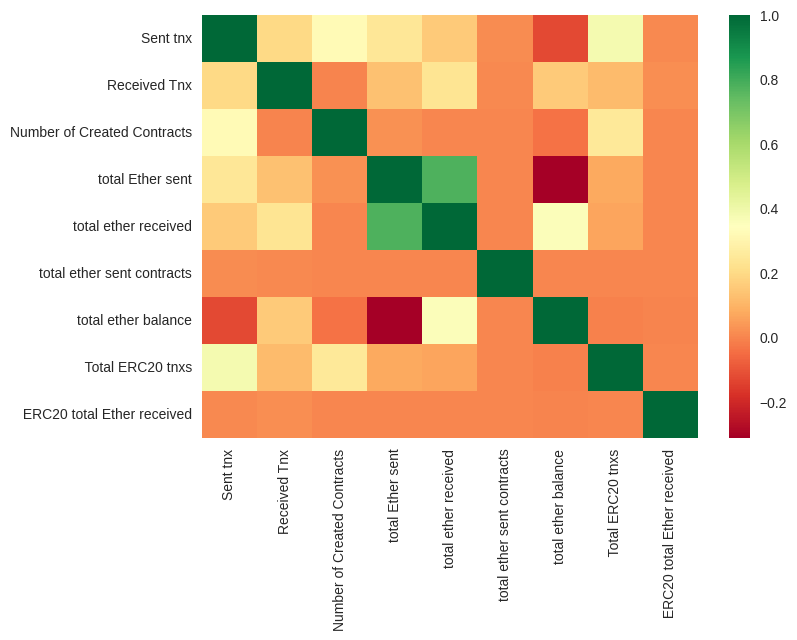

In [ ]:
sns.heatmap(df.drop("FLAG" , axis = 1).corr(),cmap='RdYlGn')

In [ ]:
df

,FLAG,Sent tnx,Received Tnx,Number of Created Contracts,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received
0,0,721,89,0,865.691093,586.466675,0.0,-279.224419,265.000000,3.558854e+07
1,0,94,8,0,3.087297,3.085478,0.0,-0.001819,8.000000,4.034283e+02
2,0,2,10,0,3.588616,3.589057,0.0,0.000441,8.000000,5.215121e+02
3,0,25,9,0,1750.045862,895.399559,0.0,-854.646303,14.000000,1.711105e+04
4,0,4598,20,1,104.318883,53.421897,0.0,-50.896986,42.000000,1.628297e+05
...,...,...,...,...,...,...,...,...,...,...
9836,1,4,13,0,36.665461,36.673777,0.0,0.008316,2.000000,1.337000e+00
9837,1,0,0,0,0.000000,0.000000,0.0,0.000000,1.000000,1.337000e+01
9838,1,67,43,0,61.785995,53.070252,0.0,-8.715743,5.000000,1.503470e+03
9839,1,0,1,0,0.000000,0.500000,0.0,0.500000,36.255659,1.296207e+08


In [ ]:
pip install pycaret

In [ ]:
from pycaret.classification import *

In [ ]:
setup(df, target = 'FLAG')

,Description,Value
0,Session id,4252
1,Target,FLAG
2,Target type,Binary
3,Original data shape,"(9841, 10)"
4,Transformed data shape,"(9841, 10)"
5,Transformed train set shape,"(6888, 10)"
6,Transformed test set shape,"(2953, 10)"
7,Numeric features,9
8,Preprocess,True
9,Imputation type,simple


In [ ]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9717,0.9926,0.9075,0.9631,0.9341,0.9161,0.9170,0.1750
rf,Random Forest Classifier,0.9704,0.9925,0.8944,0.9697,0.9304,0.9116,0.9129,0.9100
lightgbm,Light Gradient Boosting Machine,0.9702,0.9926,0.9043,0.9594,0.9307,0.9118,0.9127,2.3840
gbc,Gradient Boosting Classifier,0.9644,0.9890,0.8767,0.9593,0.9159,0.8934,0.8950,1.1790
et,Extra Trees Classifier,0.9614,0.9901,0.8636,0.9586,0.9081,0.8837,0.8860,0.5450
ada,Ada Boost Classifier,0.9575,0.9839,0.8695,0.9350,0.9005,0.8735,0.8749,0.3390
dt,Decision Tree Classifier,0.9535,0.9326,0.8951,0.8957,0.8951,0.8653,0.8655,0.0670
knn,K Neighbors Classifier,0.9476,0.9422,0.8302,0.9257,0.8749,0.8419,0.8442,0.1100
lr,Logistic Regression,0.8282,0.8232,0.2342,0.6745,0.3454,0.3006,0.3596,0.9730
dummy,Dummy Classifier,0.7786,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0420


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
rf = create_model('rf');

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9768,0.9944,0.9211,0.9722,0.9459,0.9312,0.9317
1,0.9695,0.9877,0.8816,0.9781,0.9273,0.9081,0.9101
2,0.9797,0.9957,0.9276,0.9792,0.9527,0.9398,0.9403
3,0.9550,0.9907,0.8366,0.9552,0.8920,0.8637,0.8668
4,0.9434,0.9871,0.8039,0.9318,0.8632,0.8277,0.8313
5,0.9681,0.9920,0.8693,0.9852,0.9236,0.9035,0.9064
6,0.9710,0.9970,0.9085,0.9586,0.9329,0.9144,0.9149
7,0.9550,0.9877,0.8366,0.9552,0.8920,0.8637,0.8668
8,0.9680,0.9926,0.9013,0.9514,0.9257,0.9053,0.9059


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
tuned_rf = tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9753,0.9940,0.9211,0.9655,0.9428,0.9270,0.9275
1,0.9710,0.9889,0.8882,0.9783,0.9310,0.9127,0.9144
2,0.9797,0.9956,0.9276,0.9792,0.9527,0.9398,0.9403
3,0.9550,0.9871,0.8366,0.9552,0.8920,0.8637,0.8668
4,0.9434,0.9849,0.8039,0.9318,0.8632,0.8277,0.8313
5,0.9565,0.9890,0.8431,0.9556,0.8958,0.8684,0.8712
6,0.9681,0.9954,0.8954,0.9580,0.9257,0.9054,0.9062
7,0.9521,0.9842,0.8366,0.9412,0.8858,0.8556,0.8580
8,0.9680,0.9921,0.8947,0.9577,0.9252,0.9049,0.9057


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


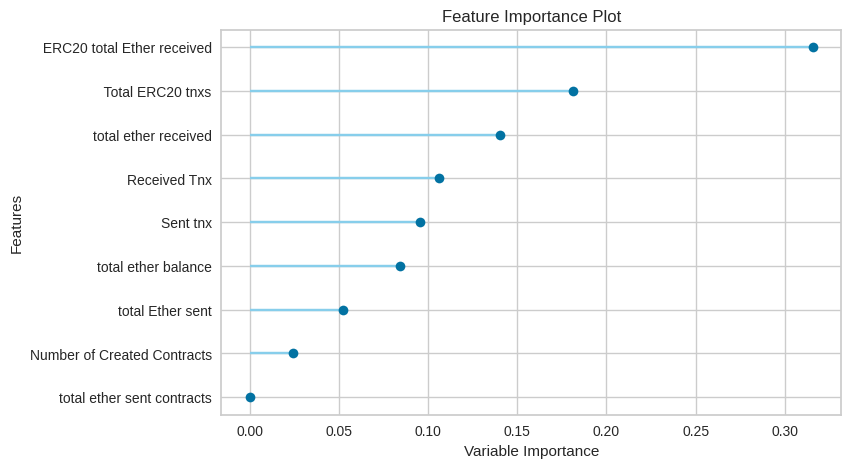

In [ ]:
plot_model(estimator = tuned_rf, plot = 'feature')

In [ ]:
xgboost = create_model('xgboost');

NameError: name 'create_model' is not defined

In [ ]:
tuned_xgboost = tune_model(xgboost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9695,0.9901,0.9211,0.9396,0.9302,0.9107,0.9108
1,0.9768,0.9875,0.9408,0.9533,0.9470,0.9322,0.9322
2,0.9768,0.9946,0.9408,0.9533,0.9470,0.9322,0.9322
3,0.9637,0.9887,0.9150,0.9211,0.9180,0.8947,0.8947
4,0.9594,0.9889,0.9150,0.9032,0.9091,0.8829,0.8830
5,0.9666,0.9908,0.9150,0.9333,0.9241,0.9027,0.9028
6,0.9681,0.9960,0.9477,0.9119,0.9295,0.9089,0.9091
7,0.9550,0.9773,0.8693,0.9236,0.8956,0.8670,0.8676
8,0.9680,0.9925,0.9342,0.9221,0.9281,0.9075,0.9076


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


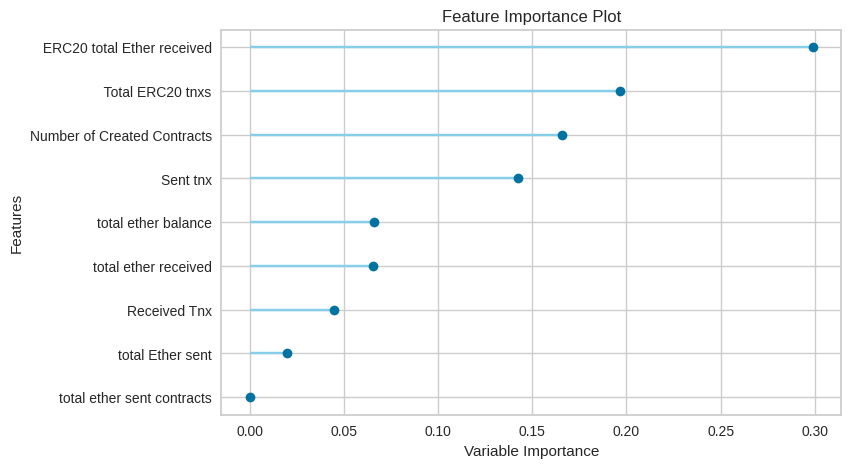

In [ ]:
plot_model(estimator = tuned_xgboost, plot = 'feature')

In [ ]:
blend = blend_models(estimator_list=[rf,xgboost])

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9797,0.9943,0.9342,0.9726,0.9530,0.9401,0.9404
1,0.9782,0.9900,0.9145,0.9858,0.9488,0.9350,0.9361
2,0.9811,0.9957,0.9276,0.9860,0.9559,0.9439,0.9447
3,0.9579,0.9910,0.8693,0.9366,0.9017,0.8750,0.8760
4,0.9536,0.9890,0.8693,0.9172,0.8926,0.8630,0.8635
5,0.9695,0.9923,0.8889,0.9714,0.9283,0.9090,0.9105
6,0.9739,0.9970,0.9150,0.9655,0.9396,0.9229,0.9235
7,0.9550,0.9882,0.8497,0.9420,0.8935,0.8650,0.8669
8,0.9753,0.9946,0.9145,0.9720,0.9424,0.9267,0.9274


Processing:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
pred = predict_model(blend)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.9743,0.9946,0.9113,0.9707,0.9401,0.9237,0.9244


In [ ]:
save_model(rf, 'rf')
save_model(xgboost, 'xgboost')

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Sent tnx', 'Received Tnx',
                                              'Number of Created Contracts',
                                              'total Ether sent',
                                              'total ether received',
                                              'total ether sent contracts',
                                              'total ether balance',
                                              ' Total ERC20 tnxs',
                                              ' ERC20 total Ether received'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_val...
                                importance_type=None,
      

In [ ]:
X = df.drop('FLAG', axis='columns')
y = df.FLAG

In [ ]:
rf = RandomForestClassifier()
xgboost = XGBClassifier()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
rf_param_grid = {
    'n_estimators': [50, 100, 200] ,
    'criterion' : [ 'entropy'],
    'max_depth' : [100,200,300],
    'random_state' : [42, 50,60]
    }

In [ ]:
grid_search1 = GridSearchCV(estimator=rf, param_grid=rf_param_grid, cv=3)
grid_search1.fit(X_train ,y_train)

GridSearchCV(cv=3, error_score=nan,
             estimator=RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                                              class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features='sqrt',
                                              max_leaf_nodes=None,
                                              max_samples=None,
                                              min_impurity_decrease=0.0,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              monotonic_cst=None,
                                              n_estimators=100, n_jobs=None,
                                              oob_score=False,
                                              random_state=None, verbose=0,
                                              warm_start=False),
             n_jobs=None,
             param_grid={'criterion': ['entropy'], 'max_depth': [100, 200, 300],
                         'n_estimators': [50, 100, 200],
                         'random_state': [42, 50, 60]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [ ]:
xgboost_param_grid = {
    'n_estimators' : [50, 100,200],
    'min_samples_split' : [2, 6, 10],
    'max_depth' : [3, 5, 7]
    }

In [ ]:
grid_search2 = GridSearchCV(estimator=xgboost, param_grid=xgboost_param_grid, cv=3)
grid_search2.fit(X_train ,y_train)

GridSearchCV(cv=3, error_score=nan,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     objective='binary:logistic', ...),
             n_jobs=None,
             param_grid={'max_depth': [3, 5, 7],
                         'min_samples_split': [2, 6, 10],
                         'n_estimators': [50, 100, 200]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0)

In [ ]:
print(grid_search1.best_score_)

print(grid_search1.best_params_)

0.9679878048780489
{'criterion': 'entropy', 'max_depth': 100, 'n_estimators': 200, 'random_state': 42}


In [ ]:
print(grid_search2.best_score_)

print(grid_search2.best_params_)

0.9710365853658537
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
best_xgboost= grid_search2.best_estimator_
xgboost_predictions = best_xgboost.predict(X_test)
xgboost_rmse = np.sqrt(mean_squared_error(y_test, xgboost_predictions))
accuracy = accuracy_score(y_test, xgboost_predictions)


xgboost_predictions_train = best_xgboost.predict(X_train)
xgboost_rmse_train = np.sqrt(mean_squared_error(y_train, xgboost_predictions_train))
xgboost_accuracy_train = accuracy_score(y_train, xgboost_predictions_train)

print("xgboost Test accuracy:", accuracy )
print("xgboost train accuracy:", xgboost_accuracy_train)

xgboost Test accuracy: 0.9710512950736414
xgboost train accuracy: 0.9983485772357723


In [ ]:
import joblib

In [ ]:
my_model = 'finalized_model.sav'
joblib.dump(best_xgboost, my_model)

['finalized_model.sav']

In [ ]:
joblib.dump(xgboost, 'xgboost_classifier_model.joblib', compress=True)

['xgboost_classifier_model.joblib']

In [ ]:
loaded_model = joblib.load('xgboost_classifier_model.joblib')

In [ ]:
pip install wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 18.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.1/302.1 kB 34.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 9.8 MB/s eta 0:00:00


In [ ]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

wandb.init(project='transaction')

best_xgboost= grid_search2.best_estimator_
xgboost_predictions = best_xgboost.predict(X_test)
xgboost_rmse = np.sqrt(mean_squared_error(y_test, xgboost_predictions))
accuracy = accuracy_score(y_test, xgboost_predictions)


xgboost_predictions_train = best_xgboost.predict(X_train)
xgboost_rmse_train = np.sqrt(mean_squared_error(y_train, xgboost_predictions_train))
xgboost_accuracy_train = accuracy_score(y_train, xgboost_predictions_train)